In [1]:
import numpy as np
from PIL import Image
import tf_keras as keras
from tf_keras import layers
from keras.applications import efficientnet

2026-04-17 10:57:34.414106: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-17 10:57:34.422767: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-17 10:57:34.431493: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-17 10:57:34.433971: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-17 10:57:34.441482: I tensorflow/core/platform/cpu_feature_guar

In [2]:
pistachio_sample = np.array(Image.open('Pistachio_Image_Dataset/Kirmizi_Pistachio/kirmizi (1).jpg'))
pistachio_sample.shape

(600, 600, 3)

In [3]:
efficientb7 = keras.applications.EfficientNetB7()
predict = efficientb7.predict(pistachio_sample[np.newaxis, :])
efficientnet.decode_predictions( predict )

I0000 00:00:1776391254.227824   10659 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-17 11:00:54.259793: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2343] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


1/1 [==============================] - 4s 4s/step


[[('n01950731', 'sea_slug', 0.23482247),
  ('n01924916', 'flatworm', 0.20674488),
  ('n01943899', 'conch', 0.086223856),
  ('n01945685', 'slug', 0.08500539),
  ('n01955084', 'chiton', 0.02824328)]]

#### 전이 학습

In [4]:
keras_efficb0_base = keras.applications.EfficientNetB0(include_top=False)
feature_map = keras_efficb0_base(pistachio_sample[np.newaxis, :])
feature_map.shape

TensorShape([1, 18, 18, 1280])

In [5]:
train_ds, val_ds = keras.utils.image_dataset_from_directory('Pistachio_Image_Dataset',
                                         image_size=(224,224), batch_size=16,
                                         validation_split=0.2, subset='both', seed=42)

Found 2150 files belonging to 2 classes.
Using 1720 files for training.
Using 430 files for validation.


In [6]:
keras_efficb0_base.trainable = False

In [7]:
inputs = keras.Input(shape=(224,224, 3))
x = keras_efficb0_base(inputs)
x = layers.GlobalAveragePooling2D() (x)
x = layers.Dense(128, activation='relu') (x)
outputs = layers.Dense(1, activation='sigmoid') (x)
model = keras.Model(inputs, outputs)

In [9]:
rmsprop = keras.optimizers.RMSprop( learning_rate=5e-5 )
model.compile( optimizer= rmsprop, loss='binary_crossentropy', metrics=['accuracy'])
hist = model.fit( train_ds , epochs=20, validation_data=val_ds )

Epoch 1/20
108/108 [==============================] - 17s 136ms/step - loss: 0.4526 - accuracy: 0.8453 - val_loss: 0.3387 - val_accuracy: 0.8977
Epoch 2/20
108/108 [==============================] - 17s 155ms/step - loss: 0.2846 - accuracy: 0.9209 - val_loss: 0.2439 - val_accuracy: 0.9186
Epoch 3/20
108/108 [==============================] - 14s 130ms/step - loss: 0.2155 - accuracy: 0.9390 - val_loss: 0.1933 - val_accuracy: 0.9233
Epoch 4/20
108/108 [==============================] - 17s 159ms/step - loss: 0.1753 - accuracy: 0.9494 - val_loss: 0.1599 - val_accuracy: 0.9465
Epoch 5/20
108/108 [==============================] - 14s 132ms/step - loss: 0.1502 - accuracy: 0.9558 - val_loss: 0.1389 - val_accuracy: 0.9558
Epoch 6/20
108/108 [==============================] - 14s 133ms/step - loss: 0.1314 - accuracy: 0.9622 - val_loss: 0.1252 - val_accuracy: 0.9605
Epoch 7/20
108/108 [==============================] - 17s 162ms/step - loss: 0.1184 - accuracy: 0.9634 - val_loss: 0.1129 - val_ac

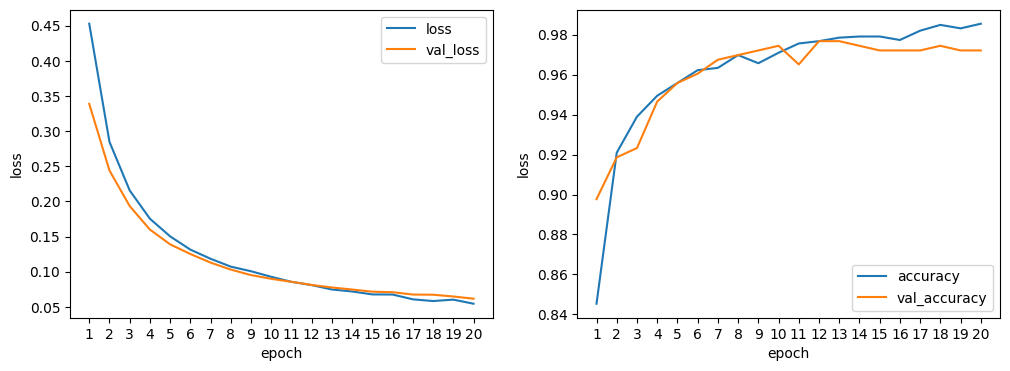

In [10]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(12,4))
axs[0].plot(range(1, 21), hist.history['loss'], label='loss')
axs[0].plot(range(1, 21), hist.history['val_loss'], label='val_loss')
axs[0].set_xticks(range(1,21))
axs[0].set_xlabel('epoch')
axs[0].set_ylabel('loss')
axs[0].legend()
axs[1].plot(range(1, 21), hist.history['accuracy'], label='accuracy')
axs[1].plot(range(1, 21), hist.history['val_accuracy'], label='val_accuracy')
axs[1].set_xticks(range(1,21))
axs[1].set_xlabel('epoch')
axs[1].set_ylabel('loss')
axs[1].legend()
plt.show()

#### 캐글 사이트에서 베이스 모델 불러오기

In [11]:
import tensorflow_hub as hub

In [14]:
kaggle_efficb0_base = hub.KerasLayer('https://www.kaggle.com/models/tensorflow/efficientnet/TensorFlow2/b0-feature-vector/1')

In [17]:
inputs = keras.Input(shape=(224,224,3))
x = layers.Rescaling(1.0/255.0) (inputs)
x = kaggle_efficb0_base(x)
x = layers.Dense(128, activation='relu') (x)
outputs = layers.Dense(1, activation='sigmoid') (x)
model = keras.Model(inputs, outputs)

rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model.compile(optimizer=rmsprop, loss='binary_crossentropy', metrics=['accuracy'])
hist = model.fit(train_ds, epochs=20, validation_data=val_ds)

Epoch 1/20
108/108 [==============================] - 15s 134ms/step - loss: 0.3860 - accuracy: 0.8738 - val_loss: 0.2470 - val_accuracy: 0.9279
Epoch 2/20
108/108 [==============================] - 11s 105ms/step - loss: 0.1980 - accuracy: 0.9459 - val_loss: 0.1726 - val_accuracy: 0.9395
Epoch 3/20
108/108 [==============================] - 14s 134ms/step - loss: 0.1418 - accuracy: 0.9610 - val_loss: 0.1287 - val_accuracy: 0.9581
Epoch 4/20
108/108 [==============================] - 12s 107ms/step - loss: 0.1121 - accuracy: 0.9663 - val_loss: 0.1071 - val_accuracy: 0.9628
Epoch 5/20
108/108 [==============================] - 12s 108ms/step - loss: 0.0936 - accuracy: 0.9750 - val_loss: 0.0951 - val_accuracy: 0.9651
Epoch 6/20
108/108 [==============================] - 15s 136ms/step - loss: 0.0803 - accuracy: 0.9756 - val_loss: 0.0843 - val_accuracy: 0.9721
Epoch 7/20
108/108 [==============================] - 12s 110ms/step - loss: 0.0705 - accuracy: 0.9797 - val_loss: 0.0759 - val_ac

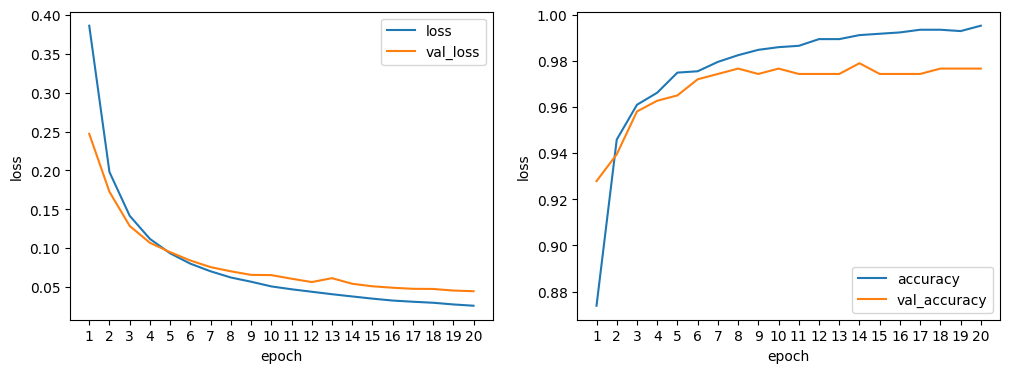

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(12,4))
axs[0].plot(range(1, 21), hist.history['loss'], label='loss')
axs[0].plot(range(1, 21), hist.history['val_loss'], label='val_loss')
axs[0].set_xticks(range(1,21))
axs[0].set_xlabel('epoch')
axs[0].set_ylabel('loss')
axs[0].legend()
axs[1].plot(range(1, 21), hist.history['accuracy'], label='accuracy')
axs[1].plot(range(1, 21), hist.history['val_accuracy'], label='val_accuracy')
axs[1].set_xticks(range(1,21))
axs[1].set_xlabel('epoch')
axs[1].set_ylabel('loss')
axs[1].legend()
plt.show()